# 02. 국내ETF(PREF01N001) EDA

스냅샷 파일 기준일: **2026-07-11** / 원본 1,734행 × 73컬럼

핵심 쟁점 두 가지:
1. 이 테이블은 **ETF와 ETN이 섞여 있다.** 분리하지 않으면 모든 통계가 오염된다.
2. 총보수·기초지수 등 **투자자가 가장 많이 묻는 필드가 대량 결측**이라 RDB 단독 답변이 불가능하다.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"

df = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260711.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PREF01N001_etf_kr_schema_20260711.csv", dtype=str, keep_default_na=False)
axis = pd.read_csv(CSV / "PREF01N001_etf_kr_axis_sample_20260711.csv", dtype=str, keep_default_na=False)
ko = dict(zip(schema.column, schema.name_ko))  # 컬럼 -> 한글명
print(df.shape, schema.shape, axis.shape)

(1734, 73) (73, 5) (100, 13)


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. ETF / ETN 분리 — 모든 통계의 전제

In [3]:
print(df.pd_grp_no.value_counts().to_string())
etf = df[df.pd_grp_no == "ETF"].copy()
etn = df[df.pd_grp_no == "ETN"].copy()
print("\nETF:", len(etf), "/ ETN:", len(etn))

pd_grp_no
ETF    1202
ETN     532

ETF: 1202 / ETN: 532


In [4]:
# 상품군별 결측률 차이 — ETN은 애초에 다른 필드 셋을 쓴다.
cmp_miss = pd.DataFrame(
    {
        "전체": (df == "").mean(),
        "ETF": (etf == "").mean(),
        "ETN": (etn == "").mean(),
    }
).round(4)
cmp_miss["한글명"] = [ko.get(c, "") for c in cmp_miss.index]
cmp_miss[(cmp_miss.ETF - cmp_miss.ETN).abs() > 0.1].sort_values("전체", ascending=False)

,전체,ETF,ETN,한글명
cu_charge_rt,0.8749,0.8195,1.0000,총보수요율
du_er_ytd,0.1482,0.1131,0.2274,수익률_YTD
du_er_3m,0.1321,0.0982,0.2086,수익률_3M
du_diff_rt,0.1251,0.0541,0.2857,괴리율
du_upt_dt,0.1251,0.0541,0.2857,일간갱신일자
du_nav_yday,0.1251,0.0541,0.2857,전일NAV
du_nav_rnf_amt,0.1251,0.0541,0.2857,전일NAV등락금액
du_er_1m,0.1119,0.0699,0.2068,수익률_1M
du_chas_errt,0.1055,0.0499,0.2312,추적오차율
cu_upt_dt,0.1055,0.0499,0.2312,변동갱신일자


> **시사점:** 1,734행 중 **ETN 532건(30.7%)** 이 섞여 있다. ETN은 총보수(cu_charge_rt) 100% 결측, 운용전략은 전부 `C`로 채워지는 등 스키마 사용 방식이 다르다. "국내 ETF는 몇 개인가" 같은 기본 질의조차 `pd_grp_no=='ETF'` 필터 없이는 30% 과대 계상되므로, 온톨로지에서 **ETF와 ETN은 형제 클래스로 분리**해야 한다. 이하 통계는 별도 표기가 없으면 ETF 1,202건 기준.

## 2. 기준일 3종

In [5]:
pd.DataFrame(
    {
        "du_upt_dt(일간)": df.du_upt_dt.replace("", "(결측)").value_counts().head(5),
        "cu_upt_dt(변동)": df.cu_upt_dt.replace("", "(결측)").value_counts().head(5),
        "wu_upt_dt(주간)": df.wu_upt_dt.replace("", "(결측)").value_counts().head(5),
    }
)

,du_upt_dt(일간),cu_upt_dt(변동),wu_upt_dt(주간)
(결측),217.0,183.0,5.0
2026-06-15 00:00:00,1517.0,NaN,NaN
20260511,NaN,4.0,NaN
20260520,NaN,8.0,NaN
20260601,NaN,5.0,NaN
20260615,NaN,1517.0,1729.0


> **시사점:** 세 갱신일 모두 최빈값이 **2026-06-15/16**으로, 파일명 기준일(2026-07-11)보다 약 4주 이르다. 가격·수익률은 6월 중순 스톡이며 "오늘 종가"류 질의는 답할 수 없다. 국내채권(2026-02-24)과도 기준일이 달라 **데이터셋 간 시점 정합이 없다** — 교차 비교 답변에는 각 소스의 기준일을 함께 제시해야 한다.

## 3. 결측의 벽 — "RDB 단독으로 답변 불가" 컬럼

In [6]:
wall = []
for c in df.columns:
    s = etf[c]
    nun = s[s != ""].nunique()
    wall.append(
        {
            "컬럼": c,
            "한글명": ko.get(c, ""),
            "ETF결측률": round((s == "").mean(), 4),
            "고유값수(결측제외)": nun,
            "판정": (
                "전량결측" if (s == "").all()
                else "상수(정보량0)" if nun <= 1
                else "고결측(>50%)" if (s == "").mean() > 0.5
                else "사용가능"
            ),
        }
    )
wall = pd.DataFrame(wall)
wall[wall.판정 != "사용가능"].sort_values(["판정", "ETF결측률"], ascending=[True, False]).reset_index(drop=True)

,컬럼,한글명,ETF결측률,고유값수(결측제외),판정
0,cu_base_index,기초지수,0.9517,19,고결측(>50%)
1,cu_charge_rt,총보수요율,0.8195,17,고결측(>50%)
2,du_diff_rt,괴리율,0.0541,1,상수(정보량0)
3,du_upt_dt,일간갱신일자,0.0541,1,상수(정보량0)
4,du_chas_errt,추적오차율,0.0499,1,상수(정보량0)
5,pd_divd_amt_pshr,주당 배당금,0.0499,1,상수(정보량0)
6,pd_dvid_yield,배당수익률,0.0499,1,상수(정보량0)
7,pd_net_ast_pshr,주당 순자산,0.0499,1,상수(정보량0)
8,pd_net_prft_pshr,주당 순이익,0.0499,1,상수(정보량0)
9,pd_net_rt_ast_pshr,주당 순자산비율,0.0499,1,상수(정보량0)


In [7]:
# 대표 사례를 수치로 못박는다.
for c in ["cu_charge_rt", "cu_base_index", "du_chas_errt", "pd_dvid_cycl", "pd_sect_nm", "nru_mkt_inav", "ru_mkt_price"]:
    s = etf[c]
    print(f"{c:18s} ({ko.get(c,''):8s}) 결측 {(s=='').mean():6.1%}  값 {list(s[s!=''].unique()[:3])}")

cu_charge_rt       (총보수요율   ) 결측  81.9%  값 ['0.49', '0', '0.4']
cu_base_index      (기초지수    ) 결측  95.2%  값 ['종합채권 3개월~1년', 'MSCI ACWI CR 50% + 종합채권01Y 50%', 'KOSPI200']
du_chas_errt       (추적오차율   ) 결측   5.0%  값 ['0.00']
pd_dvid_cycl       (당주기     ) 결측 100.0%  값 []
pd_sect_nm         (ETF 섹터명 ) 결측 100.0%  값 []
nru_mkt_inav       (장중 iNAV ) 결측 100.0%  값 []
ru_mkt_price       (현재가     ) 결측 100.0%  값 []


> **시사점:** 총보수 81.9%·기초지수 95.2% 결측, 추적오차율은 유효행 전부 `0.00`(계산되지 않음), 배당주기·ETF섹터명·실시간 시세(`ru_*`/`nru_*`)는 전량 결측이다. 즉 **"보수가 가장 싼 ETF는?", "이 ETF가 추종하는 지수는?", "분배금은 언제 나오나?"** 는 이 RDB만으로 답할 수 없다. 온톨로지에서는 해당 속성을 정의하되 **값 없음을 명시(`unknown`)** 하고, RAG 파이프라인은 이 필드에 대해 외부 문서(투자설명서·거래소 공시) 검색으로 라우팅하도록 설계해야 한다.

## 4. 순자산 3종 — 표준 1개 확정

In [8]:
aum = pd.DataFrame(
    {
        "pd_net_tamt(순자산총액)": num(etf.pd_net_tamt),
        "du_last_aum(최종AUM)": num(etf.du_last_aum),
        "pd_circ_net_tamt(유통순자산)": num(etf.pd_circ_net_tamt),
    }
)
pd.concat([aum.notna().sum().rename("유효건수"), aum.describe().T], axis=1).round(0)

,유효건수,count,mean,std,min,25%,50%,75%,max
pd_net_tamt(순자산총액),1142,1142.0,4.373214e+11,1.515419e+12,89211572.0,1.929641e+10,6.257811e+10,2.631998e+11,2.835916e+13
du_last_aum(최종AUM),1044,1044.0,4.378779e+11,1.563548e+12,0.0,1.956790e+10,6.257984e+10,2.587940e+11,2.835916e+13
pd_circ_net_tamt(유통순자산),1142,1142.0,2.166770e+11,9.881180e+11,0.0,0.000000e+00,9.845000e+09,7.816552e+10,1.902949e+13


In [9]:
print("상관계수:")
print(aum.corr().round(4).to_string())
both = aum.dropna(subset=["pd_net_tamt(순자산총액)", "du_last_aum(최종AUM)"])
rel = (both["du_last_aum(최종AUM)"] - both["pd_net_tamt(순자산총액)"]).abs() / both["pd_net_tamt(순자산총액)"].replace(0, np.nan)
print("\n두 값의 상대 차이:")
print(rel.describe().round(4).to_string())
print("\n1% 이상 차이나는 종목:", int((rel > 0.01).sum()))

상관계수:
                         pd_net_tamt(순자산총액)  du_last_aum(최종AUM)  pd_circ_net_tamt(유통순자산)
pd_net_tamt(순자산총액)                   1.0000              0.9998                   0.6200
du_last_aum(최종AUM)                   0.9998              1.0000                   0.6228
pd_circ_net_tamt(유통순자산)              0.6200              0.6228                   1.0000

두 값의 상대 차이:
count    1044.0000
mean        0.0085
std         0.0563
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         1.0000



1% 이상 차이나는 종목: 139


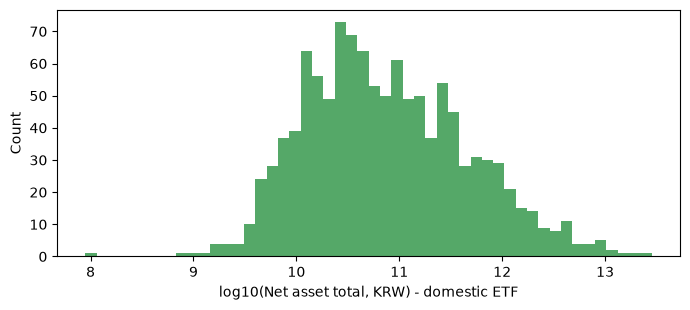

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.2))
np.log10(aum["pd_net_tamt(순자산총액)"].dropna().clip(lower=1)).plot.hist(bins=50, ax=ax, color="#55A868")
ax.set_xlabel("log10(Net asset total, KRW) - domestic ETF")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

> **시사점:** `pd_net_tamt`와 `du_last_aum`은 상관 0.9998로 동일 지표지만 유효건수가 다르고(1,142 vs 1,044) **139종목은 1% 이상 값이 어긋난다**. 반면 `pd_circ_net_tamt`(유통순자산)은 상관 0.62에 25%분위가 0으로, 전혀 다른 개념(유통주식 기준)이다. **`pd_net_tamt`을 표준 AUM으로 단일 채택**한다 — 세 개를 모두 노출하면 "이 ETF 순자산은?"에 서로 다른 숫자가 나가는 사고가 난다. 규모는 로그정규 분포로 최소 0.9억 ~ 최대 28.4조까지 6자리 스케일 차이가 나므로 "대형 ETF"는 분위수로 정의해야 한다.

## 5. 괴리율(du_diff_rt)·추적오차율(du_chas_errt) — 계산되지 않은 지표

In [11]:
dr, ce = num(etf.du_diff_rt), num(etf.du_chas_errt)
pd.DataFrame({"du_diff_rt(괴리율)": dr.describe(), "du_chas_errt(추적오차율)": ce.describe()}).round(4)

,du_diff_rt(괴리율),du_chas_errt(추적오차율)
count,1137.0,1142.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [12]:
print("du_diff_rt 유효값 종류 :", sorted(etf.du_diff_rt[etf.du_diff_rt != ""].unique())[:5])
print("du_chas_errt 유효값 종류:", sorted(etf.du_chas_errt[etf.du_chas_errt != ""].unique())[:5])
print()
# 종가와 NAV가 실제로는 다른데도 괴리율이 0으로 적재되어 있다 → 미계산의 증거
chk = etf[(etf.du_clpr != "") & (etf.du_last_nav != "")].copy()
chk["재계산_괴리율"] = (num(chk.du_clpr) / num(chk.du_last_nav) - 1) * 100
print("종가/NAV로 직접 재계산한 괴리율:")
print(chk.재계산_괴리율.describe().round(4).to_string())
print("\n|재계산 괴리율| > 1% 종목:", int((chk.재계산_괴리율.abs() > 1).sum()))
chk.loc[chk.재계산_괴리율.abs().sort_values(ascending=False).head(6).index,
        ["pd_abrv_nm", "du_clpr", "du_last_nav", "du_diff_rt", "재계산_괴리율"]]

du_diff_rt 유효값 종류 : ['0.00']
du_chas_errt 유효값 종류: ['0.00']

종가/NAV로 직접 재계산한 괴리율:
count     1142.0000
mean        17.4508
std        520.7901
min       -100.0000
25%          0.2334
50%          1.6473
75%          4.5196
max      17600.1244

|재계산 괴리율| > 1% 종목: 762


,pd_abrv_nm,du_clpr,du_last_nav,du_diff_rt,재계산_괴리율
290,ACE 러시아MSCI(합성),8535.00,48.22,0.00,17600.124430
1085,VITA 밸류알파액티브,0.00,20614.43,,-100.000000
1708,TIGER 미국나스닥100ETF선물,0.00,15228.83,,-100.000000
929,BNK 26-06 특수채(AAA이상)액티브,0.00,51732.08,,-100.000000
1140,SOL 조선TOP3플러스레버리지,18245.00,15889.54,0.00,14.823966
1296,TIGER 일본반도체FACTSET,31250.00,27329.39,0.00,14.345765


> **시사점:** 괴리율·추적오차율은 결측이 아닌 **전 종목 `0.00`으로 채워진 껍데기**다(유효값 종류가 `0.00` 단 하나). 그런데 같은 행의 종가와 NAV로 직접 계산하면 1% 넘는 괴리가 다수 나온다 — 즉 **적재값을 그대로 답하면 "모든 ETF의 괴리율은 0%"라는 명백한 오답**이 나간다. 온톨로지에는 이 두 컬럼을 싣지 않고, 필요 시 `종가/NAV`에서 **파생 계산 속성**으로 정의해야 한다.

## 6. 분류 축 실측 · 주최측 7축 대조

In [13]:
for c in ["wu_inv_ast_type", "wu_inv_rgn", "cu_lev_fector", "cu_strtegy", "pd_sect_cd", "pd_risk_nm", "pd_pen_tr_yn", "pd_pen_risk_nm"]:
    print(f"=== {c} ({ko.get(c,'')})")
    print(etf[c].replace("", "(결측)").value_counts().head(12).to_string(), "\n")

=== wu_inv_ast_type (투자자산군)
wu_inv_ast_type
주식      860
채권      184
혼합자산     77
단기자금     28
원자재      25
부동산      16
통화       12 

=== wu_inv_rgn (투자지역)
wu_inv_rgn
국내         695
미국         319
글로벌         72
중국          42
아시아         33
남미/북미       12
인도          12
유럽           6
이머징/브릭스      5
일본           5
베트남          1 

=== cu_lev_fector (배수)
cu_lev_fector
1       1038
2         62
(결측)      60
-1        32
-2        10 

=== cu_strtegy (운용전략)
cu_strtegy
실물복제    745
액티브     343
합성복제     82
(결측)     32 

=== pd_sect_cd (ETF 섹터코드)
pd_sect_cd
2       1126
(결측)      60
8         16 

=== pd_risk_nm (상품등급명)
pd_risk_nm
높은위험(2등급)      666
매우높은위험(1등급)    231
낮은위험(5등급)      115
보통위험(4등급)       85
다소높은위험(3등급)     84
매우낮은위험(6등급)     21 

=== pd_pen_tr_yn (연금거래가능여부)
pd_pen_tr_yn
Y    1001
N     201 

=== pd_pen_risk_nm (연금거래위험구분)
pd_pen_risk_nm
위험자산    787
안전자산    214
N       201 



In [14]:
# 정체불명 cu_strtegy='C' 409건의 정체 규명
print(pd.crosstab(df.cu_strtegy.replace("", "(결측)"), df.pd_grp_no).to_string())
print("\ncu_strtegy=='C' 인 상품 예시:")
print(df.loc[df.cu_strtegy == "C", "pd_abrv_nm"].head(8).to_string())

pd_grp_no   ETF  ETN
cu_strtegy          
(결측)         32  123
C             0  409
실물복제        745    0
액티브         343    0
합성복제         82    0

cu_strtegy=='C' 인 상품 예시:
1              키움 바이오TOP10 ETN
5             KB 레버리지 밀 선물 ETN
8        한투 인버스2X엔달러 선물 ETN(H)
13         N2 레버리지 천연가스 선물 ETN
14          KB 인버스 2X 은 선물 ETN
22      KB 인버스 2X 구리 선물 ETN(H)
24    신한 레버리지 다우존스지수 선물 ETN(H)
25        미래에셋 미국 자율주행대표기업 ETN


In [15]:
# pd_sect_cd는 코드만 있고 명칭(pd_sect_nm)이 전량 결측 → 다른 컬럼으로 의미 역추정
pd.crosstab(etf.pd_sect_cd.replace("", "(결측)"), etf.wu_inv_ast_type)

wu_inv_ast_type,단기자금,부동산,원자재,주식,채권,통화,혼합자산
pd_sect_cd,,,,,,,
(결측),2,2,1,32,20,0,3
2,26,14,24,812,164,12,74
8,0,0,0,16,0,0,0


In [16]:
# 연금 관련: pd_pen_tr_yn == 'N' 이면 pd_pen_risk_nm 도 'N' 으로 채워진다(값이 아니라 플래그 재사용)
pd.crosstab(df.pd_pen_tr_yn, df.pd_pen_risk_nm)

pd_pen_risk_nm,N,안전자산,위험자산
pd_pen_tr_yn,,,
N,732,0,0
Y,0,214,788


In [17]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")]
pd.DataFrame([{"축": c, "값 분포": dict(axis[c].value_counts())} for c in axis_cols])

,축,값 분포
0,axis_assetType,"{'Equity': 53, 'Bond': 16, 'MoneyMarket': 8, 'MixedAsset..."
1,axis_region,"{'Domestic': 71, 'Overseas': 29}"
2,axis_strategy,"{'Passive': 77, 'Active': 23}"
3,axis_replicationMethod,"{'Physical': 97, 'Synthetic': 3}"
4,axis_leverageType,"{'Standard': 84, 'Leveraged2X': 6, 'Inverse1X': 5, 'Inve..."
5,axis_underlyingScope,"{'SectorTheme': 69, 'MarketRepresentative': 26, 'SingleS..."
6,axis_distributionType,"{'Distributing': 99, 'TotalReturn': 1}"


In [18]:
pd.DataFrame(
    [
        ("axis_assetType", "wu_inv_ast_type", "가능", "주식/채권/원자재/혼합/단기자금/통화/부동산 8종, 결측 0%"),
        ("axis_region", "wu_inv_rgn", "가능", "국내/해외 이분은 wu_inv_rgn=='국내' 여부로 직접 산출"),
        ("axis_strategy", "cu_strtegy", "부분", "액티브 343건은 명시, 나머지는 Passive로 간주해야 함(ETN은 'C')"),
        ("axis_replicationMethod", "cu_strtegy", "부분", "실물복제/합성복제로 대응하나 ETN·결측 187건은 판정 불가"),
        ("axis_leverageType", "cu_lev_fector", "가능", "ETF는 1/2/-1/-2 4종(±3·±0.5·±1.5는 ETN 전용)"),
        ("axis_underlyingScope", "(없음)", "불가", "시장대표/섹터테마/개별종목 구분 컬럼 부재 → 상품명 파싱 필요"),
        ("axis_distributionType", "(없음)", "불가", "pd_dvid_cycl 전량 결측, TR 여부는 상품명 'TR' 토큰뿐"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_assetType,wu_inv_ast_type,가능,"주식/채권/원자재/혼합/단기자금/통화/부동산 8종, 결측 0%"
1,axis_region,wu_inv_rgn,가능,국내/해외 이분은 wu_inv_rgn=='국내' 여부로 직접 산출
2,axis_strategy,cu_strtegy,부분,"액티브 343건은 명시, 나머지는 Passive로 간주해야 함(ETN은 'C')"
3,axis_replicationMethod,cu_strtegy,부분,실물복제/합성복제로 대응하나 ETN·결측 187건은 판정 불가
4,axis_leverageType,cu_lev_fector,가능,ETF는 1/2/-1/-2 4종(±3·±0.5·±1.5는 ETN 전용)
5,axis_underlyingScope,(없음),불가,시장대표/섹터테마/개별종목 구분 컬럼 부재 → 상품명 파싱 필요
6,axis_distributionType,(없음),불가,"pd_dvid_cycl 전량 결측, TR 여부는 상품명 'TR' 토큰뿐"


In [19]:
# underlyingScope / distributionType 을 상품명 토큰으로 근사할 수 있는지 실측
print("상품명에 'TR' 포함:", int(etf.pd_abrv_nm.str.contains(r"TR\b|TR$", regex=True).sum()), "건")
print("상품명에 '(H)'(환헤지) 포함:", int(etf.pd_abrv_nm.str.contains(r"\(H\)").sum()), "건")
print("상품명에 '레버리지|인버스' 포함:", int(etf.pd_abrv_nm.str.contains("레버리지|인버스").sum()), "건")
print("상품명에 '커버드콜' 포함:", int(etf.pd_abrv_nm.str.contains("커버드콜").sum()), "건")

상품명에 'TR' 포함: 18 건
상품명에 '(H)'(환헤지) 포함: 66 건
상품명에 '레버리지|인버스' 포함: 110 건
상품명에 '커버드콜' 포함: 58 건


> **시사점:** 7축 중 3축(assetType/region/leverageType)만 컬럼으로 깨끗이 재현되고, `cu_strtegy` 하나가 **운용전략(액티브/패시브)과 복제방식(실물/합성)이라는 서로 다른 두 축을 한 컬럼에 우겨 넣은 상태**다. 온톨로지에서는 이를 `strategy`와 `replicationMethod` 두 속성으로 분리해야 한다. 결정적으로 `cu_strtegy=='C'` 409건은 **전부 ETN**이며(ETF에는 0건) 운용전략 값이 아니라 상품군 플래그의 잔재다 — 이 값을 전략으로 해석하면 안 된다. `underlyingScope`·`distributionType`은 대응 컬럼이 아예 없어 상품명 파싱이 유일한 경로다.

## 7. 브랜드 파싱 — 존재하지 않는 상품 판정

In [20]:
df["brand"] = df.pd_abrv_nm.str.split().str[0]
etf["brand"] = etf.pd_abrv_nm.str.split().str[0]
brand_tbl = pd.crosstab(df.brand, df.pd_grp_no)
brand_tbl["합계"] = brand_tbl.sum(axis=1)
brand_tbl.sort_values("합계", ascending=False).head(25)

pd_grp_no,ETF,ETN,합계
brand,,,
KODEX,240,0,240
TIGER,235,0,235
RISE,147,0,147
ACE,114,0,114
메리츠,0,92,92
PLUS,90,0,90
SOL,81,0,81
KIWOOM,77,0,77
신한,0,71,71


In [21]:
# 브랜드 ↔ 운용사 표기 매핑 (cu_fund_mgmt_co 는 97종으로 표기가 혼재)
print("cu_fund_mgmt_co 고유:", df.cu_fund_mgmt_co.nunique())
bm = (
    df.groupby("brand")
    .agg(상품수=("pd_itm_no", "size"), 운용사표기=("cu_fund_mgmt_co", lambda s: sorted(set(s))), 상품군=("pd_grp_no", lambda s: sorted(set(s))))
    .sort_values("상품수", ascending=False)
)
bm.head(20)

cu_fund_mgmt_co 고유: 97


,상품수,운용사표기,상품군
brand,,,
KODEX,240,"[삼성, 삼성KODEX, 삼성KODEX10년국채선물인버스증권상장지수투자신탁[채권-파생형], 삼성KOD...",[ETF]
TIGER,235,"[미래에셋, 미래에셋TIGER, 미래에셋TIGER200IT증권상장지수투자신탁(주식), 미래에셋TIGE...",[ETF]
RISE,147,[KB],[ETF]
ACE,114,[한국투자],[ETF]
메리츠,92,[메리츠증권 주식회사],[ETN]
PLUS,90,"[한화, 한화PLUS]",[ETF]
SOL,81,"[신한, 신한SOL유럽탄소배출권선물인버스ICE특별자산상장지수투자신탁[탄소배출권-파생형](H)]",[ETF]
KIWOOM,77,[키움],[ETF]
신한,71,[신한투자증권 주식회사],[ETN]


In [22]:
# 운용사 표기 혼재 실태: 같은 운용사가 법인격 유무로 여러 표기를 가진다
mg = df.cu_fund_mgmt_co.value_counts()
print(mg.head(20).to_string())
print("\n표기 정규화(법인격·공백 제거) 후 고유수:",
      df.cu_fund_mgmt_co.str.replace(r"\s+|주식회사|\(주\)|㈜|증권", "", regex=True).nunique(),
      "← 원본", df.cu_fund_mgmt_co.nunique())

cu_fund_mgmt_co
삼성             224
미래에셋           193
KB             147
한국투자           114
메리츠증권 주식회사      92
한화              86
신한              80
키움              77
신한투자증권 주식회사     71
한국투자증권(주)       70
삼성증권(주)         70
KB증권(주)         66
NH-Amundi       62
미래에셋증권 주식회사     58
엔에이치투자증권(주)     41
하나              28
키움증권(주)         26
하나증권주식회사        24
삼성액티브           23
타임폴리오           19

표기 정규화(법인격·공백 제거) 후 고유수: 90 ← 원본 97


In [23]:
# "존재하지 않는 상품" 판정 로직 시연
KNOWN_BRANDS = set(df.brand.unique())


def lookup(q):
    """자연어 상품명 질의 → (브랜드 유효성, 정확일치, 브랜드내 유사후보)"""
    tok = q.split()[0]
    if tok not in KNOWN_BRANDS:
        return f'"{q}" → 브랜드 "{tok}" 자체가 존재하지 않음 (환각 방지: 즉시 부정 응답)'
    exact = df[df.pd_abrv_nm.str.replace(" ", "") == q.replace(" ", "")]
    if len(exact):
        return f'"{q}" → 정확 일치 {len(exact)}건: {exact.pd_itm_no.iloc[0]}'
    key = q.replace(tok, "").replace(" ", "")
    cand = df[(df.brand == tok) & df.pd_abrv_nm.str.replace(" ", "").str.contains(re.escape(key[:3]), regex=True)]
    return f'"{q}" → 브랜드는 존재하나 해당 상품 없음. 같은 브랜드 유사 후보 {len(cand)}건: {cand.pd_abrv_nm.head(3).tolist()}'


for q in ["KODEX AI로봇", "KODEX 반도체", "TIGER 미국S&P500", "NOSUCH 성장주"]:
    print(lookup(q))

"KODEX AI로봇" → 브랜드는 존재하나 해당 상품 없음. 같은 브랜드 유사 후보 0건: []
"KODEX 반도체" → 정확 일치 1건: KR7091160002
"TIGER 미국S&P500" → 정확 일치 1건: KR7360750004
"NOSUCH 성장주" → 브랜드 "NOSUCH" 자체가 존재하지 않음 (환각 방지: 즉시 부정 응답)


> **시사점:** 상품약어명 선두 토큰이 곧 브랜드이며 KODEX 240 / TIGER 235 / RISE 147 / ACE 114 순이다. 브랜드는 **ETF와 ETN이 완전히 배타적**이다 — ETF는 영문 브랜드(KODEX·TIGER·RISE…), ETN은 증권사 한글명(메리츠·신한·한투·삼성·KB…)을 쓴다. 즉 브랜드 토큰만으로 상품군을 판정할 수 있다. 반면 `cu_fund_mgmt_co`는 "삼성"/"삼성증권(주)"/"삼성액티브"로 표기가 갈리는 데다 **일부 행에는 운용사 대신 상품 정식명칭이 통째로 들어가 있어**("삼성KODEX10년국채선물인버스증권상장지수투자신탁[채권-파생형]") 운용사 필터로 쓸 수 없다. 온톨로지에는 브랜드를 `ProductBrand` 노드로 세우고 운용사는 정규화 사전을 따로 만들어 연결해야 한다. `lookup()`이 보여주듯 **브랜드는 실재하지만 상품이 없는 경우("KODEX AI로봇")를 "브랜드 유효 + 상품 부재"로 분해 판정**하면, 그럴듯한 이름의 존재하지 않는 상품에 대한 환각을 구조적으로 차단할 수 있다.

## 8. 유효 상품 판정 (상장/판매/거래정지)

In [24]:
print("pd_lste_dt(거래종료일) 99991231 = 존속:", int((df.pd_lste_dt == "99991231").sum()))
print(pd.crosstab([df.pd_lste_dt == "99991231", df.pd_sale_yn], df.pd_tr_yn.replace("", "(결측)")).to_string())

pd_lste_dt(거래종료일) 99991231 = 존속: 1521


pd_tr_yn               (결측)     0   1
pd_lste_dt pd_sale_yn                
False      0              1   141  71
True       0              0     0   1
           1              0  1520   0


In [25]:
alive = (etf.pd_lste_dt == "99991231") & (etf.pd_sale_yn == "1") & (etf.pd_tr_yn == "0")
print("『현재 유효한 국내 ETF』 =", int(alive.sum()), "/ 전체 ETF", len(etf))
print("\n제외 사유별:")
print("  상장폐지 예정/완료 :", int((etf.pd_lste_dt != "99991231").sum()))
print("  판매중지(sale_yn=0):", int((etf.pd_sale_yn != "1").sum()))
print("  거래정지(tr_yn=1)  :", int((etf.pd_tr_yn == "1").sum()))

『현재 유효한 국내 ETF』 = 1139 / 전체 ETF 1202

제외 사유별:


  상장폐지 예정/완료 : 62
  판매중지(sale_yn=0): 63
  거래정지(tr_yn=1)  : 62


> **시사점:** `pd_lste_dt='99991231'`이 "종료일 미정=존속" sentinel이다. 세 조건을 모두 만족하는 **유효 ETF는 1,139건**(전체 ETF 1,202건 중 63건 제외)이며, 세 조건은 거의 같은 종목을 가리켜 사실상 하나의 상태 플래그다. `pd_tr_yn`이 "거래정지여부"인데 값이 `0`=정상인 역방향 플래그라 부호를 뒤집어 읽으면 결과가 정반대가 된다(스키마 한글명 오타 '상품거래정지혀부'도 그대로 존재).

## 9. 수익률 6종 — 결측 계단과 극단값

In [26]:
ers = ["du_er_1d", "du_er_1m", "du_er_3m", "du_er_6m", "du_er_ytd", "du_er_1y"]
pd.DataFrame(
    {
        "한글명": [ko.get(c, "") for c in ers],
        "ETF결측률": [round((etf[c] == "").mean(), 4) for c in ers],
        "min": [num(etf[c]).min() for c in ers],
        "median": [round(num(etf[c]).median(), 2) for c in ers],
        "max": [num(etf[c]).max() for c in ers],
    },
    index=ers,
)

,한글명,ETF결측률,min,median,max
du_er_1d,수익률_1D,0.0449,-12.1,1.69,14.14
du_er_1m,수익률_1M,0.0699,-100.0,1.20,50.76
du_er_3m,수익률_3M,0.0982,-100.0,6.98,350.19
du_er_6m,수익률_6M,0.1190,-100.0,11.06,818.57
du_er_ytd,수익률_YTD,0.1131,-100.0,13.48,701.69
du_er_1y,수익률_1Y,0.1797,-100.0,32.63,2738.95


In [27]:
# 장기 수익률 결측 = 신규 상장 종목인지 확인
etf["lstg"] = pd.to_datetime(etf.pd_lstg_dt.where(etf.pd_lstg_dt.str.fullmatch(r"\d{8}")), format="%Y%m%d", errors="coerce")
print("du_er_1y 결측 종목의 상장일 분포:")
print(etf.loc[etf.du_er_1y == "", "lstg"].dt.year.value_counts().sort_index().to_string())
print("\ndu_er_1y 유효 종목의 상장일 중앙값:", etf.loc[etf.du_er_1y != "", "lstg"].median())

du_er_1y 결측 종목의 상장일 분포:
lstg
2021.0      3
2022.0      8
2023.0      5
2025.0    106
2026.0     93

du_er_1y 유효 종목의 상장일 중앙값: 2022-03-25 12:00:00


> **시사점:** 1D→1Y로 갈수록 결측이 계단식으로 늘어난다(4.5%→18.0%). 1Y 결측 종목의 199/215가 2025~2026년 상장으로, **결측 = 데이터 누락이 아니라 "이력이 아직 없음"** 이다. RAG는 이 둘을 구분해 "1년 수익률 없음"이 아니라 "상장 1년 미만이라 산출 불가"로 답해야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| ETN 혼입 | 532건(30.7%) | ETF/ETN 형제 클래스 분리 필수 |
| 총보수 결측(ETF) | 81.9% | 보수 비교 질의 = 외부 소스 라우팅 |
| 기초지수 결측(ETF) | 95.2% | 지수 엔티티 연결 사실상 불가 |
| 전량결측·상수 컬럼 | 20개 이상 | 온톨로지 미탑재 |
| 괴리율·추적오차율 | 전 종목 `0.00` (미계산) | 적재값 사용 금지, 종가/NAV 파생 계산 |
| cu_strtegy='C' | 409건 전부 ETN | 전략값 아님, 오독 위험 |
| 유효 ETF | 1,139 / 1,202 | 상장·판매·거래 3조건 동시 적용 |
| 브랜드 | KODEX 240 / TIGER 235 … | ETF=영문·ETN=한글로 배타적 |